In [297]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [298]:
#read in file
df = pd.read_csv('PositronBeam_2p86GeV/Beam_FeasibilityStudy_20260421.dat', sep=r'\s+')
print(list(df.columns))

['x[mm]', 'xp[mrad]', 'y[mm]', 'yp[mrad]', 't[mm/c]', 'p[MeV/c]', 'ID']


In [299]:
#calculating the emittance

def CalcEmittanceManual(df, position, angle):
    pos = df[position].values
    ang = df[angle].values

    x_c= pos-np.mean(pos)
    xp_c= ang-np.mean(ang)

    x2_mean = np.mean(x_c**2)
    xp2_mean = np.mean(xp_c**2)
    xxp_mean = np.mean(x_c * xp_c)
    
    emittance = np.sqrt(x2_mean * xp2_mean - xxp_mean**2)

    return emittance

def CalcEmittanceAuto(df, position, angle):
    pos = df[position].values
    ang = df[angle].values
    cov = np.cov(pos, ang) 
    emittance=np.sqrt(np.linalg.det(cov))
    return emittance


In [300]:
subset_id=np.random.choice(df['ID'], size=1000, replace=False)
subset = df[df['ID'].isin(subset_id)]


In [301]:
ids = df['ID'].unique()
first_1000_list = ids[:1000]
subset=df[df['ID'].isin(first_1000_list)]

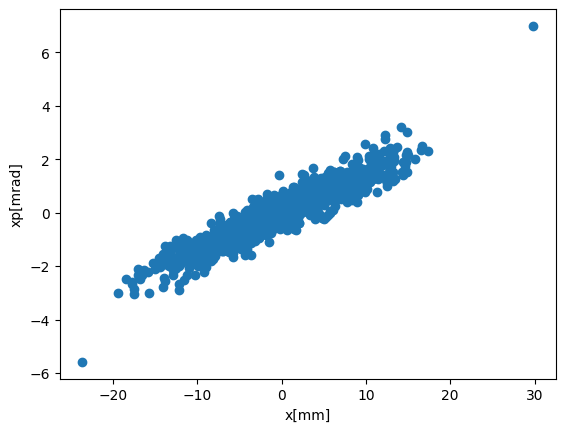

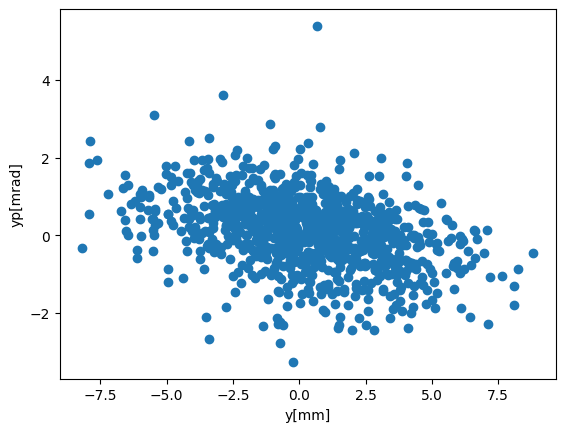

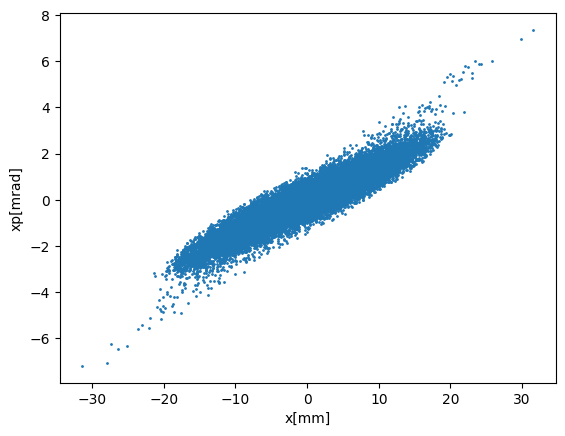

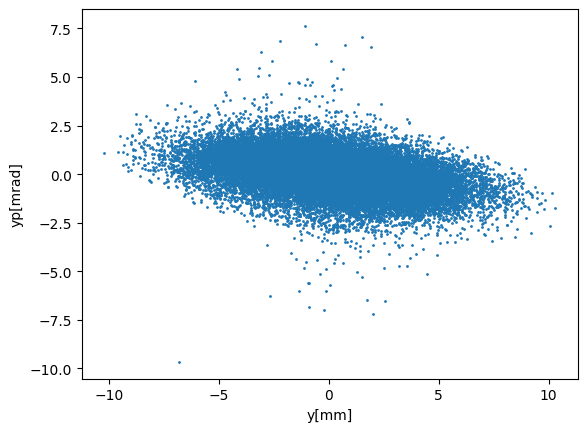

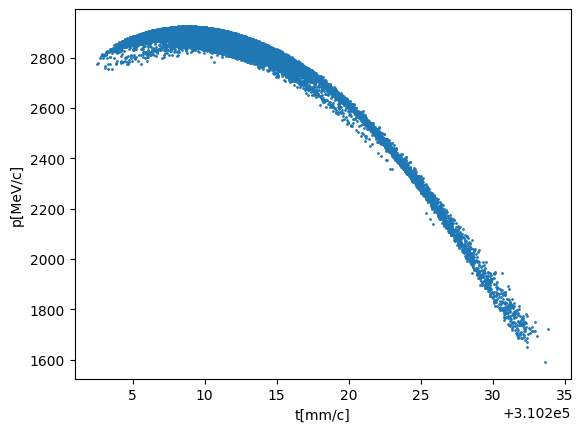

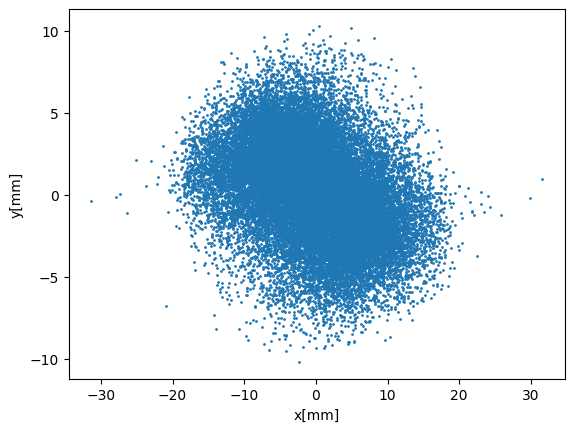

Horizontal geometric emittance:2737.2087910544365 nm, 2737.1283771530125nm
Vertical geometric emittance:2585.950249047885 nm, 2585.874278829926nm


In [302]:
plt.scatter(subset['x[mm]'],subset['xp[mrad]'])
plt.xlabel('x[mm]')
plt.ylabel('xp[mrad]')
plt.show()

plt.scatter(subset['y[mm]'],subset['yp[mrad]'])
plt.xlabel('y[mm]')
plt.ylabel('yp[mrad]')
plt.show()

plt.scatter(df['x[mm]'],df['xp[mrad]'], s=1)
plt.xlabel('x[mm]')
plt.ylabel('xp[mrad]')
plt.show()

plt.scatter(df['y[mm]'],df['yp[mrad]'], s=1)
plt.xlabel('y[mm]')
plt.ylabel('yp[mrad]')
plt.show()

main_bunch = df[df['t[mm/c]'] < 310250]
plt.scatter(main_bunch['t[mm/c]'],main_bunch['p[MeV/c]'], s=1)
plt.xlabel('t[mm/c]')
plt.ylabel('p[MeV/c]')
plt.show()

plt.scatter(df['x[mm]'],df['y[mm]'], s=1)
plt.xlabel('x[mm]')
plt.ylabel('y[mm]')
plt.show()

emittance=CalcEmittanceAuto(df, 'x[mm]', 'xp[mrad]')
m_emittance=CalcEmittanceManual(df, 'x[mm]', 'xp[mrad]')
print(f'Horizontal geometric emittance:{emittance*1e3} nm, {m_emittance*1e3}nm' )
emittance=CalcEmittanceAuto(df, 'y[mm]', 'yp[mrad]')
m_emittance=CalcEmittanceManual(df, 'y[mm]', 'yp[mrad]')
print(f'Vertical geometric emittance:{emittance*1e3} nm, {m_emittance*1e3}nm' )

In [303]:
p_array=df['p[MeV/c]']

p_avg = np.mean(p_array)
rms_spread = np.std(p_array)  
relative_spread = (rms_spread / p_avg) *100

print(f"RMS Momentum Spread: {relative_spread} %")


RMS Momentum Spread: 5.880652238961275 %
